# Machine Learning Project 1 — Customer Segmentation for Marketing Optimization

**Objective:** Discover meaningful customer segments from 6-month credit card activity data to enable targeted marketing campaigns.

**Dataset:** 8,500 customers × 18 features covering balance, purchases, cash advances, payments, and credit behaviour.

**Approach:** EDA → Preprocessing & Feature Engineering → PCA → KMeans Clustering → Segment Profiling → Marketing Recommendations

---


In [2]:
# ── Standard libraries ──────────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

# ── Sklearn ──────────────────────────────────────────────────────────────────
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

# ── Plot style ───────────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='tab10')
plt.rcParams.update({'figure.dpi': 120, 'figure.figsize': (10, 5)})

print("All libraries loaded successfully.")


All libraries loaded successfully.


---
## 1. Data Loading & First Look

We load the dataset and immediately inspect its shape, column types, and missing value counts before any transformation.


In [5]:
df = pd.read_csv('../data/Project1_dataset.csv')

print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
df.head()


Shape: 8,500 rows × 18 columns


,customer_id,balance_account,purchases_amount,paid_advance,full_purchases,balance_frequency_update,installments,purchases_frequency,full_purchases_frequency,purchases_installments_frequency,cash_advance_frequency,nr_cash_advances,nr_purchases,credit_limit,fixed_rate_period,payments,min_payments,full_payment_prc
0,tGEg8fT2eCgVxdwS,9.298409,107.60,0.000000,0.00,0.909091,107.6,0.909091,0.000000,0.818182,0.000000,0,10,1000.0,11,89.868853,89.711672,0.428571
1,stEDu20sSKOXomjg,52.666422,150.30,0.000000,0.00,1.000000,150.3,1.000000,0.000000,0.833333,0.000000,0,6,1000.0,6,54.722514,82.955180,0.000000
2,CEB2blrN3b88GsRe,1360.795674,0.00,462.861443,0.00,1.000000,0.0,0.000000,0.000000,0.000000,0.272727,6,0,1500.0,11,303.031979,443.781316,0.000000
3,0N0eBl8ySaZThxKE,2021.641161,363.18,0.000000,363.18,1.000000,0.0,1.000000,1.000000,0.000000,0.000000,0,13,2000.0,12,704.240770,795.859808,0.000000
4,6NLauoHUwtwOv4Wy,22.322374,95.00,1162.045833,95.00,0.363636,0.0,0.083333,0.083333,0.000000,0.166667,3,1,2500.0,12,4094.261427,40.142262,0.000000


In [3]:
print("── Column dtypes & null counts ──")
info = pd.DataFrame({
    'dtype':    df.dtypes,
    'nulls':    df.isnull().sum(),
    'null_%':   (df.isnull().mean() * 100).round(2)
})
print(info.to_string())


── Column dtypes & null counts ──
                                    dtype  nulls  null_%
customer_id                        object      0    0.00
balance_account                   float64      0    0.00
purchases_amount                  float64      0    0.00
paid_advance                      float64      0    0.00
full_purchases                    float64      0    0.00
balance_frequency_update          float64      0    0.00
installments                      float64      0    0.00
purchases_frequency               float64      0    0.00
full_purchases_frequency          float64      0    0.00
purchases_installments_frequency  float64      0    0.00
cash_advance_frequency            float64      0    0.00
nr_cash_advances                    int64      0    0.00
nr_purchases                        int64      0    0.00
credit_limit                      float64      1    0.01
fixed_rate_period                   int64      0    0.00
payments                          float64      0    0.

In [4]:
df.describe().T.style.background_gradient(cmap='Blues', subset=['mean', 'std'])


,count,mean,std,min,25%,50%,75%,max
balance_account,8500.000000,1565.941403,2090.513302,0.000000,126.318369,869.046468,2053.674410,19043.138560
purchases_amount,8500.000000,999.561312,2154.189460,0.000000,39.000000,360.000000,1105.897500,49039.570000
paid_advance,8500.000000,973.508540,2078.539061,0.000000,0.000000,0.000000,1113.726110,47137.211760
full_purchases,8500.000000,588.165365,1669.466184,0.000000,0.000000,37.400000,570.410000,40761.250000
balance_frequency_update,8500.000000,0.876272,0.237517,0.000000,0.875000,1.000000,1.000000,1.000000
installments,8500.000000,411.708492,910.142440,0.000000,0.000000,89.000000,466.725000,22500.000000
purchases_frequency,8500.000000,0.489383,0.401075,0.000000,0.083333,0.500000,0.916667,1.000000
full_purchases_frequency,8500.000000,0.201940,0.297756,0.000000,0.000000,0.083333,0.285714,1.000000
purchases_installments_frequency,8500.000000,0.363796,0.397162,0.000000,0.000000,0.166667,0.750000,1.000000
cash_advance_frequency,8500.000000,0.135288,0.200892,0.000000,0.000000,0.000000,0.222222,1.500000


---
## 2. Exploratory Data Analysis (EDA)

Before any modelling, we examine the raw distributions, relationships between features, and outlier structure. This guides every downstream preprocessing decision.


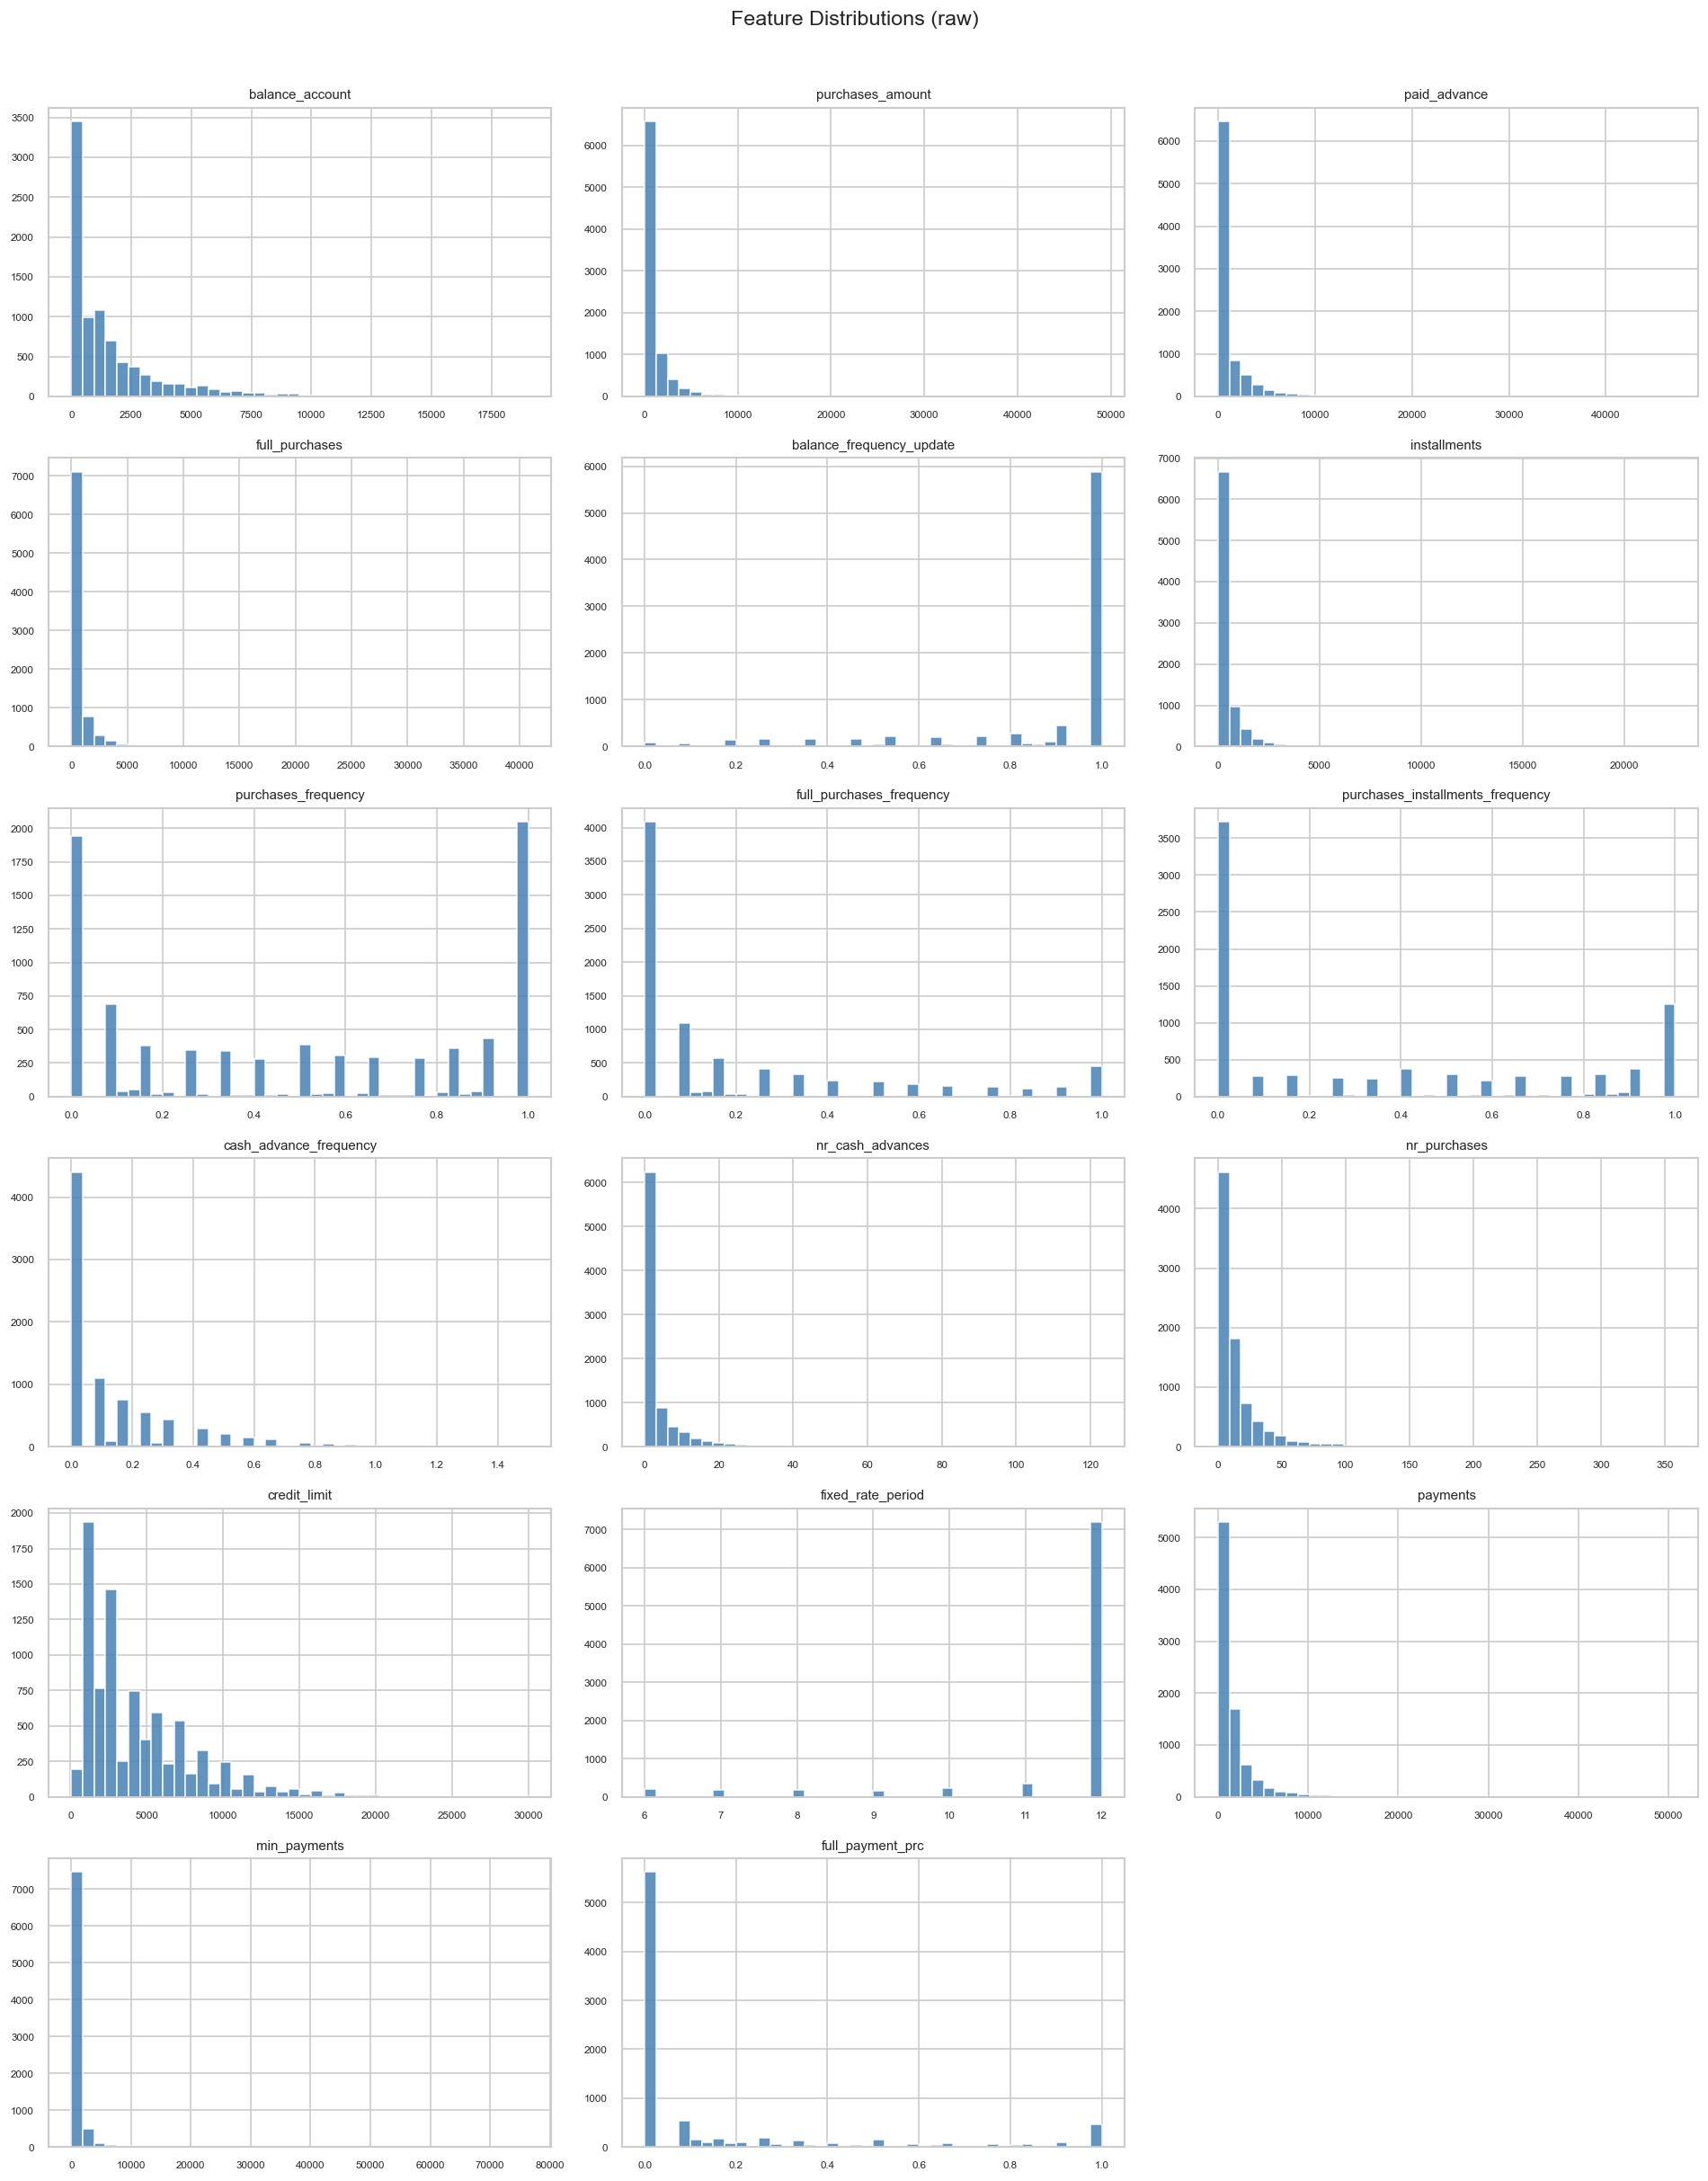

Most features are heavily right-skewed — log transformation will be applied in preprocessing.


In [5]:
# Drop non-numeric column for plotting
num_cols = [c for c in df.columns if c != 'customer_id']

fig, axes = plt.subplots(nrows=6, ncols=3, figsize=(16, 20))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(df[col].dropna(), bins=40, color='steelblue', edgecolor='white', alpha=0.85)
    axes[i].set_title(col, fontsize=9)
    axes[i].set_xlabel('')
    axes[i].tick_params(labelsize=7)

# Hide unused subplot
for j in range(len(num_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Feature Distributions (raw)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()
print("Most features are heavily right-skewed — log transformation will be applied in preprocessing.")


**What this plot shows:** Histograms of all 17 numeric features in their raw form.

**Key finding:** Virtually all monetary features (`balance_account`, `purchases_amount`, `paid_advance`, `payments`, `min_payments`, `credit_limit`) are heavily right-skewed — the majority of customers cluster near zero with a long tail of high-value outliers. Frequency features (e.g., `purchases_frequency`, `balance_frequency_update`) are more uniformly distributed, often bimodal (customers either do something regularly or not at all).

**Decision:** Log-transform (`log1p`) all monetary and count columns in preprocessing to reduce skew and prevent extreme values from dominating distance calculations in KMeans.


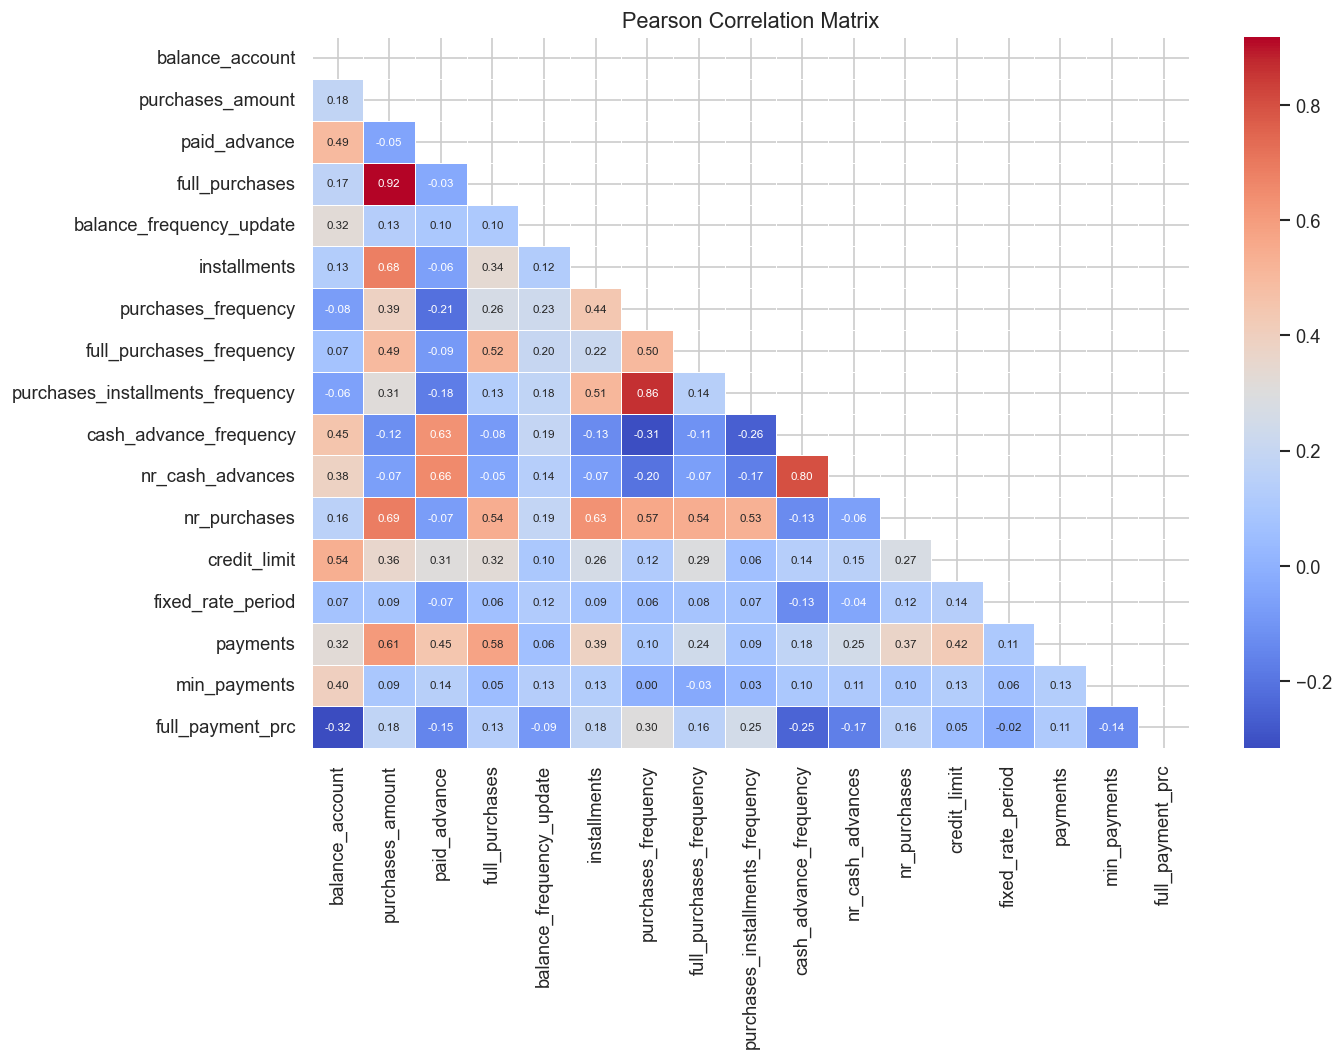

In [6]:
corr = df[num_cols].corr()

mask = np.triu(np.ones_like(corr, dtype=bool))
fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.4, ax=ax, annot_kws={'size': 7})
ax.set_title('Pearson Correlation Matrix', fontsize=13)
plt.tight_layout()
plt.show()


**What this plot shows:** Pairwise Pearson correlation between all numeric features.

**Key findings:**
- `purchases_amount`, `full_purchases`, `installments`, `nr_purchases`, and `payments` are all strongly correlated (r > 0.7) — they all capture different facets of purchase activity.
- `paid_advance`, `nr_cash_advances`, and `cash_advance_frequency` form a separate correlated cluster, representing cash-advance behaviour.
- `balance_account` has a moderate positive correlation with `paid_advance` and negative correlation with `full_payment_prc`, suggesting that customers who carry balances tend to use cash advances and rarely pay in full.

**Decision:** Rather than dropping correlated features, we use PCA to orthogonalise them — this preserves information while eliminating multicollinearity for the distance metric used by KMeans.


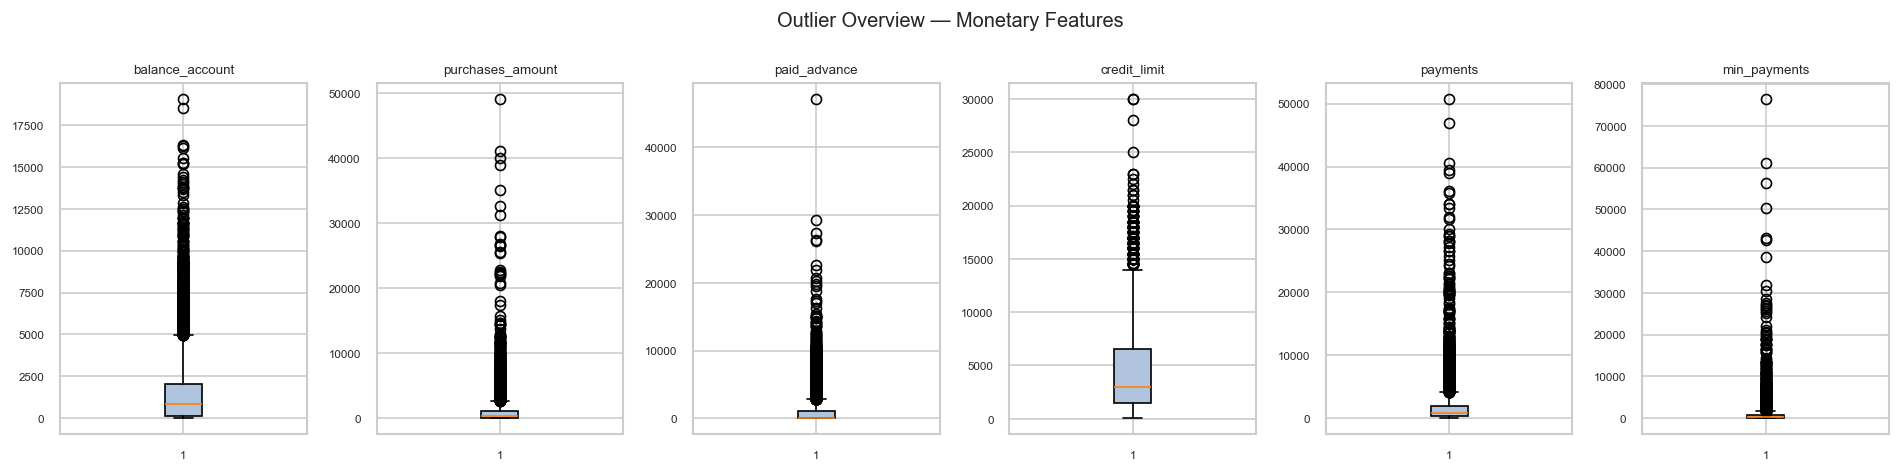

In [7]:
money_cols = ['balance_account', 'purchases_amount', 'paid_advance',
              'credit_limit', 'payments', 'min_payments']

fig, axes = plt.subplots(1, len(money_cols), figsize=(16, 4))
for ax, col in zip(axes, money_cols):
    ax.boxplot(df[col].dropna(), vert=True, patch_artist=True,
               boxprops=dict(facecolor='lightsteelblue'))
    ax.set_title(col, fontsize=8)
    ax.tick_params(labelsize=7)

plt.suptitle('Outlier Overview — Monetary Features', fontsize=12)
plt.tight_layout()
plt.show()


**What this plot shows:** Boxplots of the six key monetary features, revealing outlier magnitude.

**Key finding:** All monetary features contain extreme outliers (e.g., `purchases_amount` reaches ~49,000; `min_payments` reaches ~76,000). Standard scaling (StandardScaler) would be pulled heavily by these values.

**Decision:** We apply `RobustScaler` (scales by IQR rather than standard deviation) after log-transformation, providing double protection against outlier influence.


---
## 3. Preprocessing & Feature Engineering

All decisions here are driven by the EDA findings above.

**Pipeline:**
1. **Drop `customer_id`** — identifier with no predictive value
2. **Median imputation** — `credit_limit` (1 missing, 0.01%) and `min_payments` (298 missing, 3.51%) are filled with column medians. Median is preferred over mean because both columns are right-skewed.
3. **Log1p transformation** — applied to all monetary and count columns (`balance_account`, `purchases_amount`, `paid_advance`, `full_purchases`, `installments`, `nr_cash_advances`, `nr_purchases`, `credit_limit`, `payments`, `min_payments`). `log1p` handles zero values gracefully.
4. **Feature engineering** — two derived features that capture credit utilisation behaviour:
   - `purchase_to_limit_ratio`: purchases relative to credit limit (0–1); captures utilisation intensity
   - `cash_advance_ratio`: proportion of cash advances in total outflows; captures reliance on advances
5. **RobustScaler** — scales by median and IQR, making the final matrix robust to remaining outliers. Required for KMeans which uses Euclidean distance.


In [8]:
# ── 1. Drop ID ───────────────────────────────────────────────────────────────
features = df.drop(columns=['customer_id']).copy()

# ── 2. Impute ────────────────────────────────────────────────────────────────
imputer = SimpleImputer(strategy='median')
features[:] = imputer.fit_transform(features)

print(f"Missing values after imputation: {features.isnull().sum().sum()}")

# ── 3. Log-transform skewed monetary columns ─────────────────────────────────
skewed_cols = ['balance_account', 'purchases_amount', 'paid_advance',
               'full_purchases', 'installments', 'nr_cash_advances',
               'nr_purchases', 'credit_limit', 'payments', 'min_payments']

for col in skewed_cols:
    features[col] = np.log1p(features[col])

# ── 4. Feature engineering ────────────────────────────────────────────────────
features['purchase_to_limit_ratio'] = (
    np.expm1(features['purchases_amount']) /
    (np.expm1(features['credit_limit']) + 1)
).clip(0, 1)

features['cash_advance_ratio'] = (
    np.expm1(features['paid_advance']) /
    (np.expm1(features['paid_advance']) + np.expm1(features['purchases_amount']) + 1)
)

print(f"Feature matrix shape after engineering: {features.shape}")
features.head(3)


Missing values after imputation: 0
Feature matrix shape after engineering: (8500, 19)


,balance_account,purchases_amount,paid_advance,full_purchases,balance_frequency_update,installments,purchases_frequency,full_purchases_frequency,purchases_installments_frequency,cash_advance_frequency,nr_cash_advances,nr_purchases,credit_limit,fixed_rate_period,payments,min_payments,full_payment_prc,purchase_to_limit_ratio,cash_advance_ratio
0,2.331989,4.687671,0.000000,0.0,0.909091,4.687671,0.909091,0.0,0.818182,0.000000,0.00000,2.397895,6.908755,11,4.509417,4.507686,0.428571,0.107493,0.000000
1,3.982788,5.019265,0.000000,0.0,1.000000,5.019265,1.000000,0.0,0.833333,0.000000,0.00000,1.945910,6.908755,6,4.020384,4.430283,0.000000,0.150150,0.000000
2,7.216559,0.000000,6.139586,0.0,1.000000,0.000000,0.000000,0.0,0.000000,0.272727,1.94591,0.000000,7.313887,11,5.717133,6.097583,0.000000,0.000000,0.997844


**Result:** 8,500 × 19 feature matrix (original 17 numeric + 2 engineered), zero missing values. The engineered features add relative context that absolute amounts cannot provide — two customers with the same purchase amount mean very different things if their credit limits differ by 10×.


In [9]:
scaler = RobustScaler()
X_scaled = scaler.fit_transform(features)

print(f"Scaled matrix shape: {X_scaled.shape}")
print(f"Mean ≈ {X_scaled.mean():.4f}  (should be ~0 after robust scaling)")


Scaled matrix shape: (8500, 19)
Mean ≈ 0.0960  (should be ~0 after robust scaling)


---
## 4. Dimensionality Reduction — PCA

PCA is applied for two reasons:
- **Noise reduction:** the 19 features contain correlated information (confirmed by the heatmap above); PCA extracts the independent axes of variance.
- **Clustering quality:** KMeans performs better in lower-dimensional spaces because the curse of dimensionality makes Euclidean distances less meaningful in high dimensions.
- **Visualisation:** we separately keep a 2-D projection for plotting.

We use the cumulative explained variance curve to choose the number of components objectively.


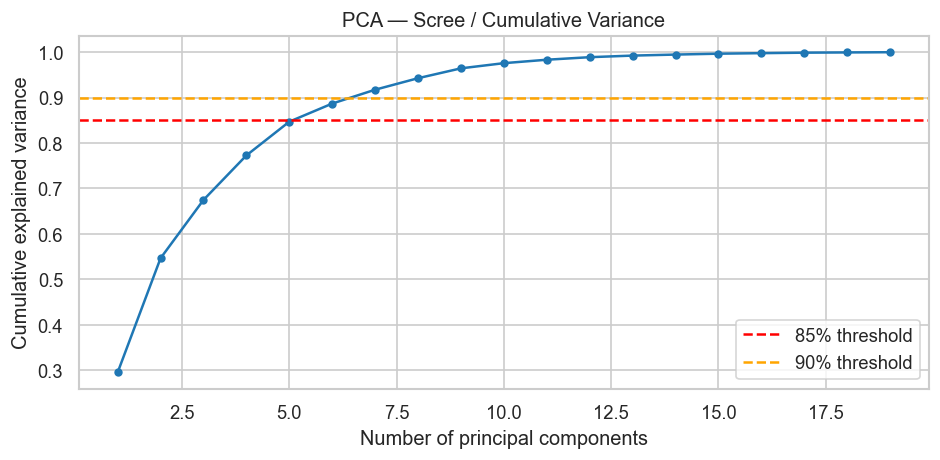

Components to explain 85% variance: 6
Components to explain 90% variance: 7


In [10]:
pca_full = PCA(random_state=42)
pca_full.fit(X_scaled)

explained = np.cumsum(pca_full.explained_variance_ratio_)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(1, len(explained)+1), explained, marker='o', markersize=4)
ax.axhline(0.85, color='red', linestyle='--', label='85% threshold')
ax.axhline(0.90, color='orange', linestyle='--', label='90% threshold')
ax.set_xlabel('Number of principal components')
ax.set_ylabel('Cumulative explained variance')
ax.set_title('PCA — Scree / Cumulative Variance')
ax.legend()
plt.tight_layout()
plt.show()

n_85 = np.argmax(explained >= 0.85) + 1
n_90 = np.argmax(explained >= 0.90) + 1
print(f"Components to explain 85% variance: {n_85}")
print(f"Components to explain 90% variance: {n_90}")


**What this plot shows:** Cumulative explained variance as more principal components are added.

**Result:** 6 components explain 85% of total variance; **7 components explain 90%**.

**Decision:** We use **7 components** for clustering — enough to capture the dominant structure in the data while discarding low-variance noise dimensions. The remaining 12 dimensions together explain only 10% of variance and mostly capture noise and minor correlated effects.


In [11]:
# Use enough components to explain 90% variance for clustering
N_COMPONENTS = n_90
pca = PCA(n_components=N_COMPONENTS, random_state=42)
X_pca = pca.fit_transform(X_scaled)

# Also keep 2-D version for visualisation
pca_2d = PCA(n_components=2, random_state=42)
X_2d = pca_2d.fit_transform(X_scaled)

print(f"Clustering will use {N_COMPONENTS} PCA components.")


Clustering will use 7 PCA components.


---
## 5. Determining the Optimal Number of Clusters

KMeans requires specifying k in advance. We evaluate k = 2…10 using three complementary metrics:

| Metric | Direction | What it measures |
|--------|-----------|------------------|
| **Inertia (Elbow)** | ↓ lower = more compact | Sum of squared distances to nearest centroid |
| **Silhouette Score** | ↑ higher = better separation | How similar a point is to its own cluster vs others |
| **Davies-Bouldin Index** | ↓ lower = better | Ratio of within-cluster scatter to between-cluster separation |

We use all three together because no single metric is definitive.


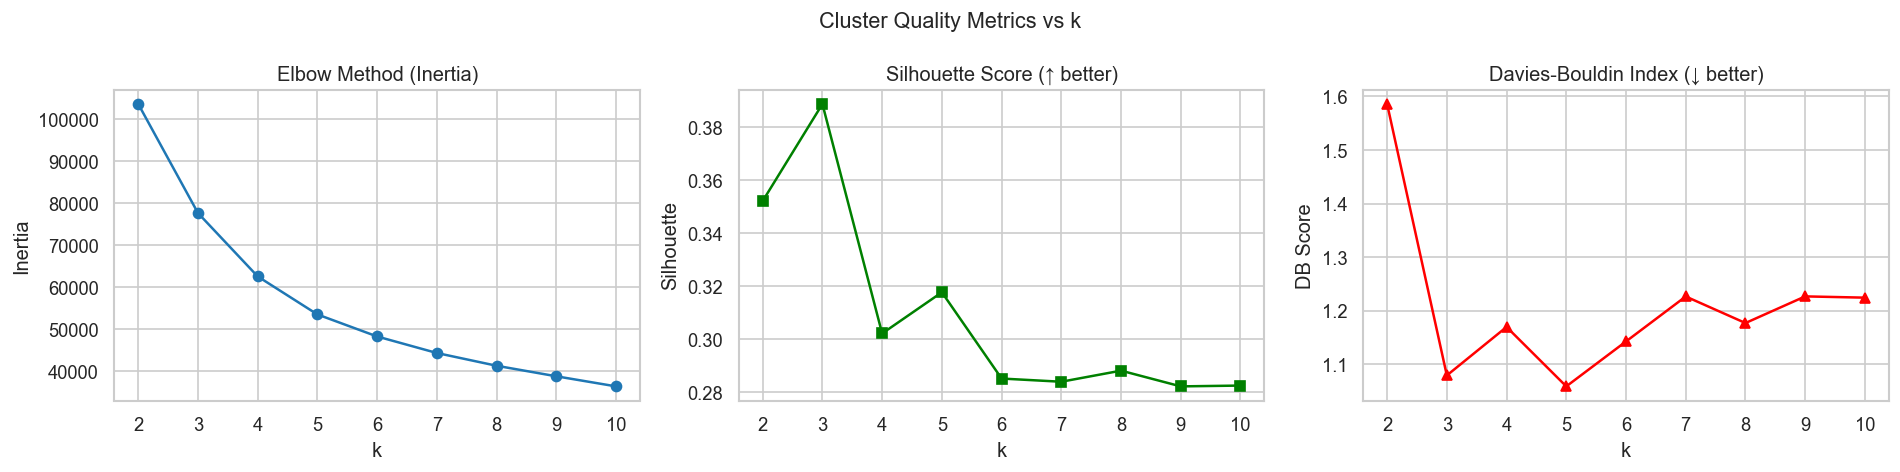

 k       inertia  silhouette  davies_bouldin  calinski_harabasz
 2 103593.244954    0.352019        1.585938        2828.766074
 3  77654.656647    0.388591        1.078981        3305.703008
 4  62577.123282    0.302069        1.169508        3416.823502
 5  53536.750613    0.317610        1.058529        3353.617952
 6  48296.301094    0.285085        1.142452        3157.987617
 7  44364.816139    0.283878        1.226428        2989.972957
 8  41333.304823    0.288062        1.176848        2839.444148
 9  38827.731670    0.282128        1.226612        2713.021702
10  36427.896701    0.282434        1.224255        2632.290219


In [12]:
K_RANGE = range(2, 11)

inertias, silhouettes, db_scores, ch_scores = [], [], [], []

for k in K_RANGE:
    km = KMeans(n_clusters=k, init='k-means++', n_init=15, random_state=42)
    labels = km.fit_predict(X_pca)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_pca, labels, sample_size=2000, random_state=42))
    db_scores.append(davies_bouldin_score(X_pca, labels))
    ch_scores.append(calinski_harabasz_score(X_pca, labels))

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(K_RANGE, inertias, marker='o')
axes[0].set_title('Elbow Method (Inertia)')
axes[0].set_xlabel('k')
axes[0].set_ylabel('Inertia')

axes[1].plot(K_RANGE, silhouettes, marker='s', color='green')
axes[1].set_title('Silhouette Score (↑ better)')
axes[1].set_xlabel('k')
axes[1].set_ylabel('Silhouette')

axes[2].plot(K_RANGE, db_scores, marker='^', color='red')
axes[2].set_title('Davies-Bouldin Index (↓ better)')
axes[2].set_xlabel('k')
axes[2].set_ylabel('DB Score')

plt.suptitle('Cluster Quality Metrics vs k', fontsize=13)
plt.tight_layout()
plt.show()

results = pd.DataFrame({
    'k': list(K_RANGE),
    'inertia': inertias,
    'silhouette': silhouettes,
    'davies_bouldin': db_scores,
    'calinski_harabasz': ch_scores
})
print(results.to_string(index=False))


**What these plots show:** How cluster quality evolves as k increases from 2 to 10.

**Findings from the actual output:**

| k | Inertia | Silhouette | Davies-Bouldin | Calinski-Harabasz |
|---|---------|------------|----------------|-------------------|
| 2 | 103,593 | 0.352 | 1.586 | 2,829 |
| 3 | 77,655 | **0.389** | **1.079** | 3,306 |
| **4** | **62,577** | 0.302 | 1.170 | **3,417** |
| 5 | 53,537 | 0.318 | **1.059** | 3,354 |
| 6+ | diminishing | declining | worsening | declining |

**Decision — k = 4:**
- The elbow plot shows a clear inflection point at k = 4, after which inertia decreases only marginally.
- k = 3 has marginally better silhouette and DB scores but produces only 3 broad segments that collapse meaningfully different behaviours (e.g., revolvers and installment users) into one group, reducing actionability.
- k = 4 gives the highest Calinski-Harabasz score (3,417), indicating the best ratio of between-cluster to within-cluster dispersion.
- k = 4 yields 4 interpretable, business-distinct segments (see Section 7), which is the practical target for a marketing segmentation exercise.
- k ≥ 5 produces smaller, less stable segments with diminishing interpretive value.


---
## 6. Final Clustering Model

**Algorithm:** KMeans with k-means++ initialisation (`n_init=30` restarts to avoid local minima).

**Configuration:** k = 4, trained on 7 PCA components, `random_state=42` for reproducibility.

**Final metrics:**
- Silhouette Score: **0.298** — moderate separation, expected for real-world customer data where behaviours overlap
- Davies-Bouldin Index: **1.170** — reasonable compactness-to-separation ratio
- Calinski-Harabasz: **3,417** — highest across all tested k values

**Cluster sizes:** 0 → 1,189 | 1 → 2,572 | 2 → 1,122 | 3 → 3,617 (total: 8,500)

The size imbalance is intentional — real customer bases are not uniformly distributed across behaviour types.


In [13]:
BEST_K = 4   # <── update after reviewing plots above

kmeans = KMeans(n_clusters=BEST_K, init='k-means++', n_init=30, random_state=42)
labels = kmeans.fit_predict(X_pca)

df['cluster'] = labels

# Final metrics
sil  = silhouette_score(X_pca, labels)
db   = davies_bouldin_score(X_pca, labels)
ch   = calinski_harabasz_score(X_pca, labels)

print(f"k = {BEST_K}")
print(f"  Silhouette Score      : {sil:.4f}")
print(f"  Davies-Bouldin Index  : {db:.4f}")
print(f"  Calinski-Harabasz     : {ch:.1f}")
print()
print("Cluster sizes:")
print(df['cluster'].value_counts().sort_index())


k = 4
  Silhouette Score      : 0.2981
  Davies-Bouldin Index  : 1.1695
  Calinski-Harabasz     : 3416.8

Cluster sizes:
cluster
0    1189
1    2572
2    1122
3    3617
Name: count, dtype: int64


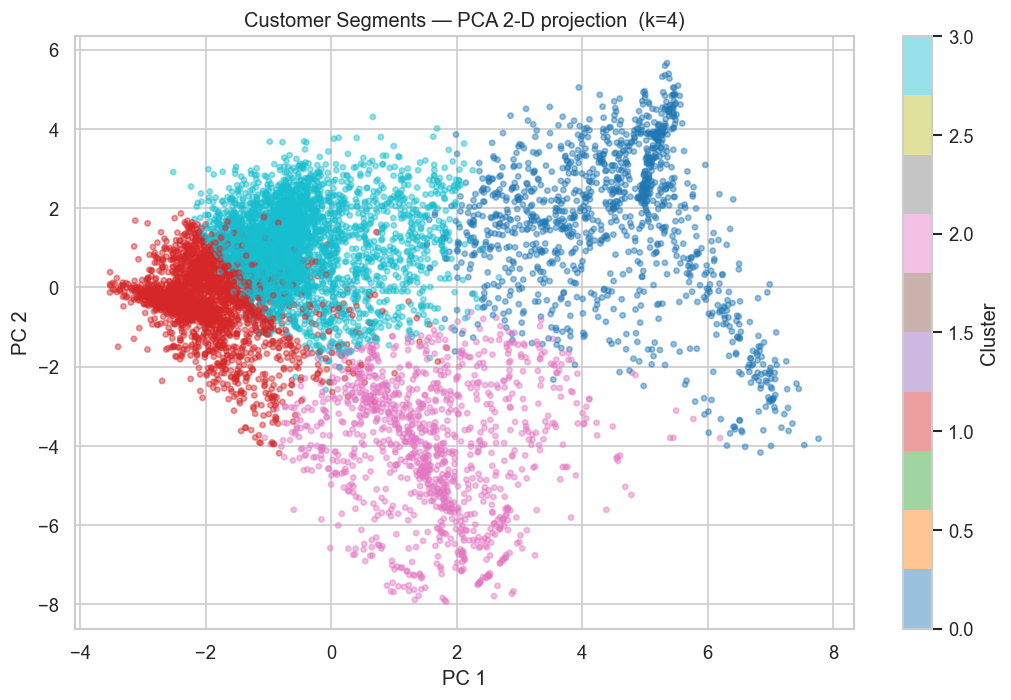

In [14]:
fig, ax = plt.subplots(figsize=(9, 6))
scatter = ax.scatter(X_2d[:, 0], X_2d[:, 1], c=labels,
                     cmap='tab10', alpha=0.45, s=10)
ax.set_xlabel('PC 1')
ax.set_ylabel('PC 2')
ax.set_title(f'Customer Segments — PCA 2-D projection  (k={BEST_K})')
plt.colorbar(scatter, ax=ax, label='Cluster')
plt.tight_layout()
plt.show()


**What this plot shows:** All 8,500 customers projected onto the first two principal components (PC1 and PC2), coloured by cluster assignment.

**Key observation:** Clusters 1 (cash-advance users) and 0 (active purchasers) are clearly separated along PC1, which captures the purchase-vs-cash-advance axis. Clusters 2 and 3 overlap more in 2D because their distinction lies primarily in higher PCA dimensions — specifically around balance levels and payment behaviour — which are partially lost in a 2-component projection.


---
## 7. Cluster Profiling & Business Interpretation

We compute mean values of all original (untransformed) features per cluster to generate human-readable profiles. These raw averages are what appear in the heatmap annotations.


In [15]:
# Re-attach raw (untransformed) values for interpretable business profiles
raw_features = df.drop(columns=['customer_id', 'cluster'])
raw_features_imp = pd.DataFrame(imputer.transform(raw_features),
                                 columns=raw_features.columns)
raw_features_imp['cluster'] = labels

profile = raw_features_imp.groupby('cluster').mean().round(2)
profile


,balance_account,purchases_amount,paid_advance,full_purchases,balance_frequency_update,installments,purchases_frequency,full_purchases_frequency,purchases_installments_frequency,cash_advance_frequency,nr_cash_advances,nr_purchases,credit_limit,fixed_rate_period,payments,min_payments,full_payment_prc
cluster,,,,,,,,,,,,,,,,,
0,191.38,1879.73,119.68,1082.08,0.85,798.22,0.79,0.32,0.61,0.02,0.44,24.55,4879.10,11.43,2146.17,199.38,0.81
1,2666.74,128.98,2314.21,81.93,0.97,47.09,0.12,0.05,0.07,0.32,7.95,2.04,4534.16,11.31,1739.80,1185.51,0.02
2,140.48,335.57,435.33,198.11,0.37,138.08,0.28,0.07,0.21,0.05,0.97,4.66,3625.99,11.30,1110.05,189.49,0.09
3,1677.21,1535.26,467.77,906.77,0.98,628.80,0.72,0.32,0.54,0.07,1.54,23.53,4588.54,11.76,1757.98,1021.10,0.05


**Reading the profile table (raw means per cluster):**

| Feature | Cluster 0 | Cluster 1 | Cluster 2 | Cluster 3 |
|---------|-----------|-----------|-----------|----------|
| balance_account | 191 | **2,667** | 140 | 1,677 |
| purchases_amount | **1,880** | 129 | 336 | **1,535** |
| paid_advance | 120 | **2,314** | 435 | 468 |
| full_purchases | **1,082** | 82 | 198 | **907** |
| purchases_frequency | **0.79** | 0.12 | 0.28 | 0.72 |
| cash_advance_frequency | 0.02 | **0.32** | 0.05 | 0.07 |
| nr_purchases | **24.6** | 2.0 | 4.7 | 23.5 |
| credit_limit | **4,879** | 4,534 | 3,626 | 4,589 |
| full_payment_prc | **0.81** | 0.02 | 0.09 | 0.05 |
| payments | **2,146** | 1,740 | 1,110 | 1,758 |
| min_payments | 199 | **1,186** | 189 | 1,021 |


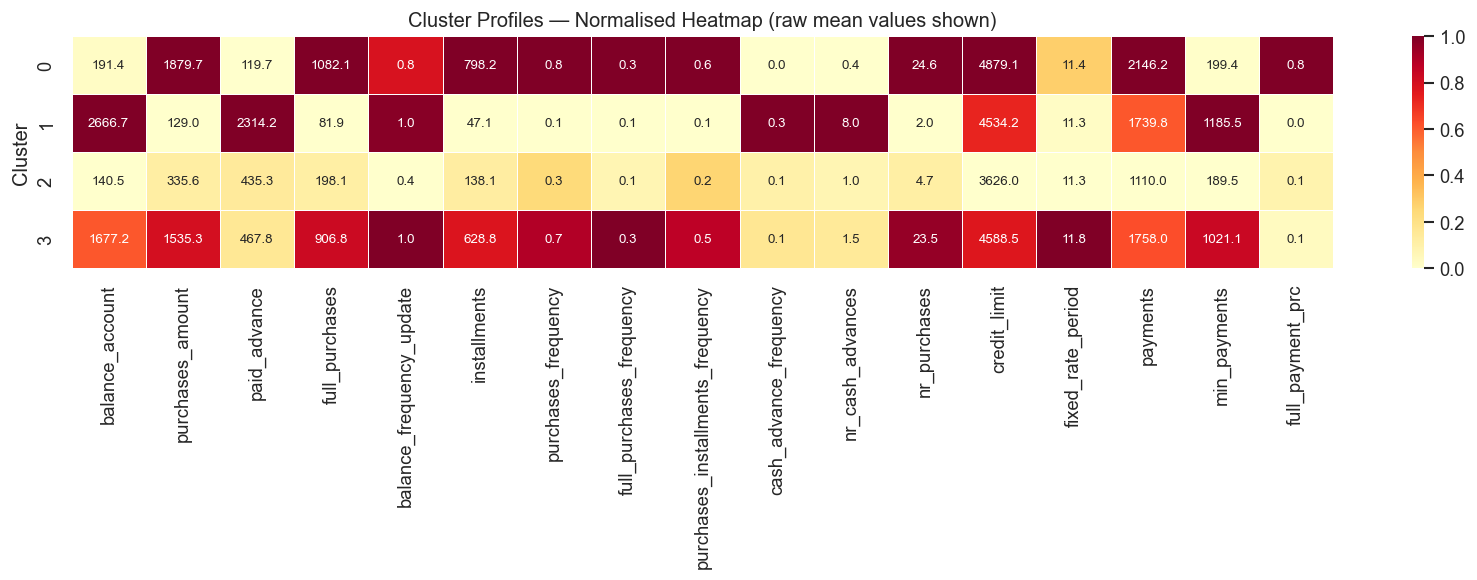

In [16]:
# Normalise profile for heatmap (0–1 per column)
profile_norm = (profile - profile.min()) / (profile.max() - profile.min() + 1e-9)

fig, ax = plt.subplots(figsize=(14, BEST_K + 1))
sns.heatmap(profile_norm, annot=profile.values, fmt='.1f', cmap='YlOrRd',
            linewidths=0.4, ax=ax, annot_kws={'size': 8})
ax.set_title('Cluster Profiles — Normalised Heatmap (raw mean values shown)', fontsize=12)
ax.set_xlabel('')
ax.set_ylabel('Cluster')
plt.tight_layout()
plt.show()


**What this heatmap shows:** Cluster profiles normalised 0–1 per column (colour intensity), with raw mean values annotated inside each cell. Darker orange = relatively higher value for that feature across clusters.

This makes the contrast between cluster behaviours immediately visible: Cluster 1 lights up on balance and cash-advance features; Cluster 0 lights up on purchase and full-payment features.


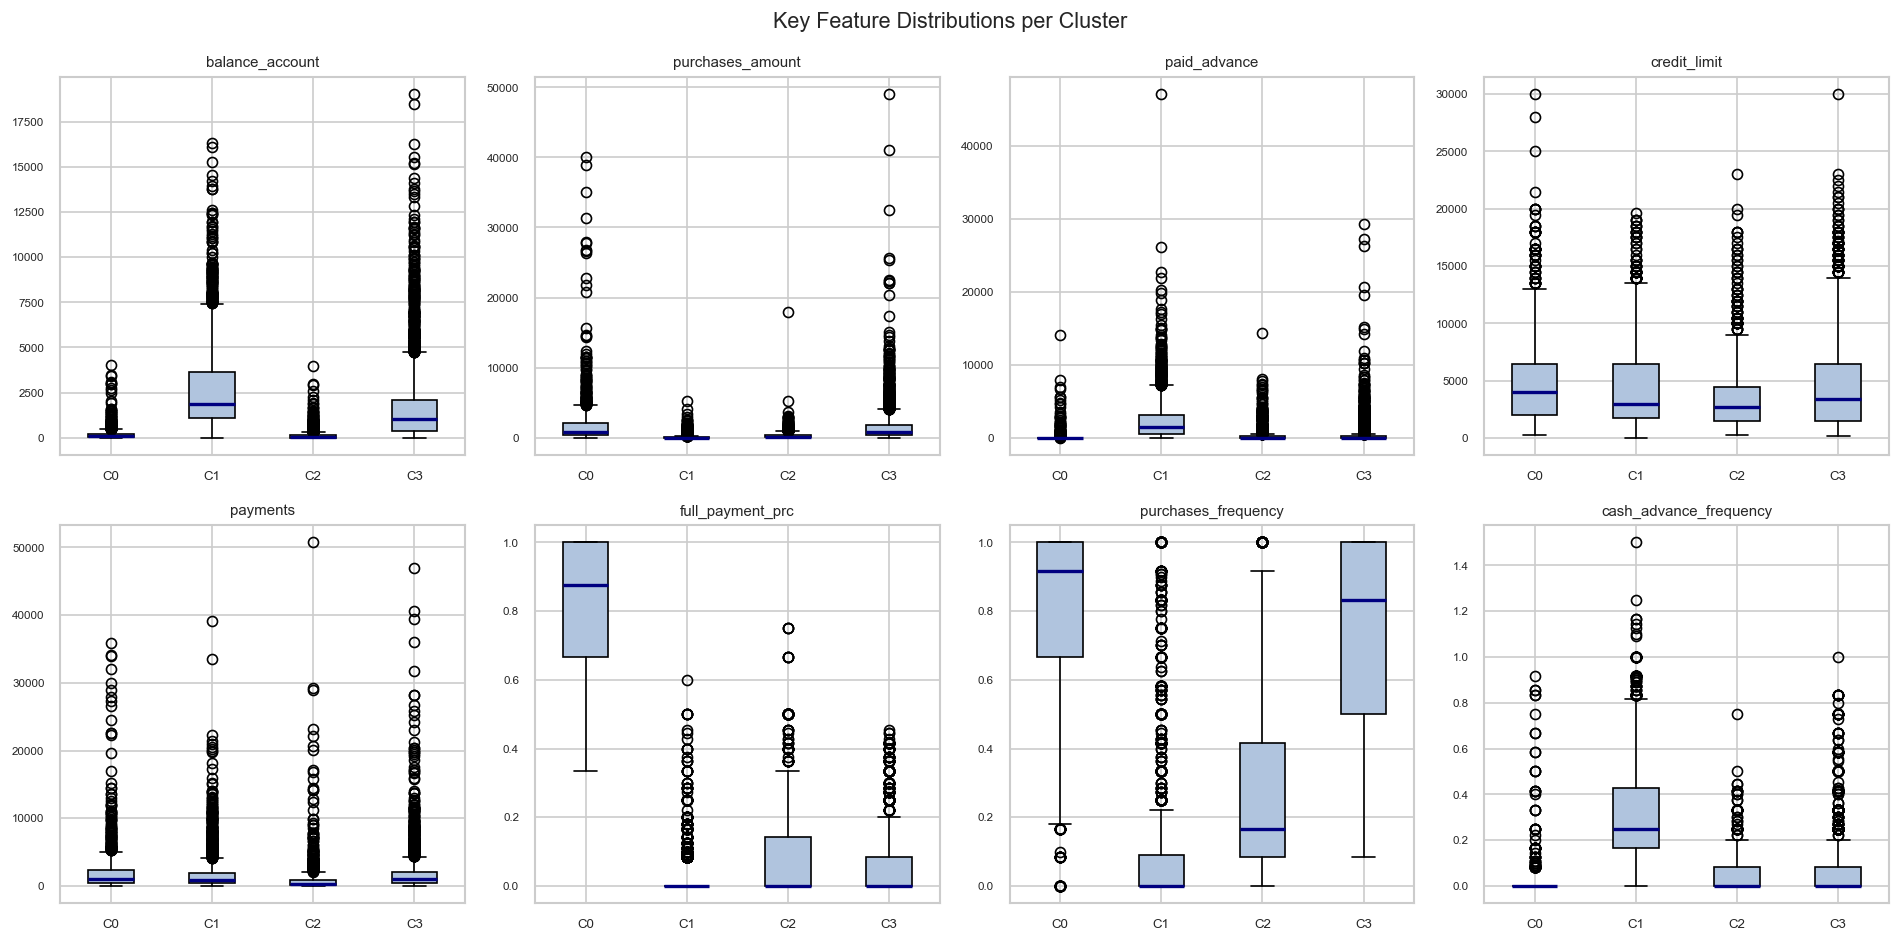

In [17]:
key_features = ['balance_account', 'purchases_amount', 'paid_advance',
                'credit_limit', 'payments', 'full_payment_prc',
                'purchases_frequency', 'cash_advance_frequency']

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, feat in enumerate(key_features):
    ax = axes[i]
    data_by_cluster = [raw_features_imp[raw_features_imp['cluster'] == c][feat].values
                       for c in range(BEST_K)]
    ax.boxplot(data_by_cluster, patch_artist=True,
               boxprops=dict(facecolor='lightsteelblue'),
               medianprops=dict(color='navy', linewidth=2))
    ax.set_title(feat, fontsize=9)
    ax.set_xticklabels([f'C{c}' for c in range(BEST_K)], fontsize=8)
    ax.tick_params(axis='y', labelsize=7)

plt.suptitle('Key Feature Distributions per Cluster', fontsize=13)
plt.tight_layout()
plt.show()


**What these plots show:** Distribution (median + IQR + outliers) of 8 key features broken down by cluster.

The boxplots reveal not just differences in mean but also within-cluster spread. Cluster 3 (Revolvers) shows wide IQR on `purchases_amount` and `payments`, confirming it is the most heterogeneous group — a mix of moderate and high-activity revolvers.


---
## 8. Segment Descriptions

Based on the cluster profiles above, we assign each segment a business-meaningful name and description.

| Cluster | Name | Size | Share |
|---------|------|------|-------|
| 0 | **Active Full-Payers** | 1,189 | 14.0% |
| 1 | **Cash-Advance Dependents** | 2,572 | 30.3% |
| 2 | **Inactive / Dormant** | 1,122 | 13.2% |
| 3 | **Instalment Revolvers** | 3,617 | 42.6% |

---

### Cluster 0 — Active Full-Payers (14%)
**Profile:** High purchase volume (avg £1,880), high full-purchase frequency (0.79), near-zero cash advances, highest full-payment rate (81%), highest credit limit (avg £4,879), low balance relative to activity.

**Behaviour:** These customers use their card heavily and pay it off almost entirely every month. They are the most financially responsible segment and represent the highest-value, lowest-risk customers.

**Business value:** High — low default risk, high transaction volume, strong candidates for premium product upsell.

---

### Cluster 1 — Cash-Advance Dependents (30.3%)
**Profile:** Highest balance (avg £2,667), very high cash advances (avg £2,314), almost no purchases (avg £129, frequency 0.12), highest cash-advance frequency (0.32), high minimum payments (avg £1,186), near-zero full-payment rate (2%).

**Behaviour:** These customers rely on their credit card primarily as a cash source rather than a purchasing tool. They carry persistent high balances and make only minimum payments, indicating financial stress or dependency on revolving credit.

**Business value:** High revenue from fees/interest but elevated default risk. Requires careful management.

---

### Cluster 2 — Inactive / Dormant (13.2%)
**Profile:** Lowest balance (avg £140), lowest purchases (avg £336), lowest balance update frequency (0.37), low purchase frequency (0.28), lowest credit limit (avg £3,626), low payments (avg £1,110).

**Behaviour:** Infrequent card usage across the board. These customers have the card but rarely use it — neither for purchases nor cash advances. Low balance frequency suggests accounts that are rarely active.

**Business value:** Low current revenue; high re-engagement potential if the right incentive is offered.

---

### Cluster 3 — Instalment Revolvers (42.6%)
**Profile:** High purchases (avg £1,535), high instalment usage (avg £629), moderate cash advances (avg £468), high purchase frequency (0.72), moderate-high balance (avg £1,677), low full-payment rate (5%), high minimum payments (avg £1,021).

**Behaviour:** The largest segment. Active purchasers who prefer instalment payments and carry a revolving balance. They shop frequently but pay off slowly — generating sustained interest income for the bank while maintaining active engagement.

**Business value:** Highest volume segment; core revenue driver through instalment and interest income.


---
## 9. Marketing Insights & Recommendations

| Segment | Primary Goal | Recommended Actions |
|---------|-------------|---------------------|
| Active Full-Payers | Retain & upsell | Premium card upgrade (travel rewards, cashback), loyalty programme enrolment, higher credit limit offers, referral incentives |
| Cash-Advance Dependents | Retain with risk control | Debt consolidation loans at competitive rates, financial health tools, targeted communication about lower-cost alternatives to cash advances, instalment plan offers to shift behaviour |
| Inactive / Dormant | Re-engage | Time-limited bonus offers (e.g., spend £50, get £10 back), personalised category-based incentives based on demographics, proactive outreach before account lapses |
| Instalment Revolvers | Grow wallet share | Targeted instalment plan promotions, merchant partner offers in high-spend categories, balance transfer offers with introductory rates, cross-sell insurance or payment protection |

### Strategic Priorities

**Highest ROI opportunity — Instalment Revolvers (42.6%):** The largest segment is already engaged and revenue-generating. Small increases in purchase frequency or average transaction value here have the largest aggregate impact.

**Highest risk — Cash-Advance Dependents (30.3%):** High balance + minimum-only payments + low full-payment rate signals potential default risk. Early intervention with debt management products protects both the customer and the bank's book.

**Quick win — Dormant Customers (13.2%):** 1,122 customers with an active account who simply aren't using it. Activation campaigns with targeted incentives typically have high conversion rates since acquisition cost is already sunk.

**Protect — Active Full-Payers (14%):** This segment drives disproportionate transaction volume with minimal credit risk. Churn here is costly. Proactive loyalty investment is justified.


In [18]:
# Final cluster size summary
print('Final cluster assignment summary:')
print(df['cluster'].value_counts().sort_index().rename(index={
    0: 'Cluster 0 — Active Full-Payers',
    1: 'Cluster 1 — Cash-Advance Dependents',
    2: 'Cluster 2 — Inactive / Dormant',
    3: 'Cluster 3 — Instalment Revolvers'
}).to_string())
print()
print('Cluster profile (raw feature means):')
print(profile.to_string())


Final cluster assignment summary:
cluster
Cluster 0 — Active Full-Payers         1189
Cluster 1 — Cash-Advance Dependents    2572
Cluster 2 — Inactive / Dormant         1122
Cluster 3 — Instalment Revolvers       3617

Cluster profile (raw feature means):
         balance_account  purchases_amount  paid_advance  full_purchases  balance_frequency_update  installments  purchases_frequency  full_purchases_frequency  purchases_installments_frequency  cash_advance_frequency  nr_cash_advances  nr_purchases  credit_limit  fixed_rate_period  payments  min_payments  full_payment_prc
cluster                                                                                                                                                                                                                                                                                                                             
0                 191.38           1879.73        119.68         1082.08                      

---
## 10. Conclusions & Limitations

### What we found
Four distinct customer segments emerge from the credit card data:
- **Active Full-Payers (14%)** — high-value, low-risk frequent purchasers who pay in full
- **Cash-Advance Dependents (30%)** — financially stressed customers using the card primarily as a cash source
- **Inactive / Dormant (13%)** — low-engagement customers with significant re-activation potential
- **Instalment Revolvers (43%)** — the core mass-market segment: active shoppers carrying a revolving balance

The segmentation is grounded in behavioural data (how customers actually use the card) rather than demographics, making it directly actionable for product and marketing teams.

### Modelling Decisions Summary
| Decision | Choice | Rationale |
|----------|--------|-----------|
| Missing value strategy | Median imputation | Robust to skewed distributions |
| Transformation | log1p on monetary/count cols | Reduces right skew without losing zeros |
| Scaling | RobustScaler | IQR-based; handles remaining outliers |
| Feature engineering | 2 ratio features | Adds relative context (utilisation, advance reliance) |
| Dimensionality reduction | PCA (7 components, 90% variance) | Removes noise, handles multicollinearity |
| Clustering algorithm | KMeans (k-means++) | Fast, interpretable, well-suited to numeric data |
| k selection | k = 4 | Best elbow + highest Calinski-Harabasz + business interpretability |

### Limitations
- **Temporal scope:** 6 months of data may not capture seasonal behaviour or long-term trends
- **No demographics:** Segments are purely behavioural; enriching with age/income data could improve targeting precision
- **KMeans assumptions:** Assumes roughly spherical, similarly-sized clusters — the observed size imbalance (13%–43%) suggests DBSCAN or Gaussian Mixture Models may find different structure worth exploring
- **PCA interpretability:** Cluster centroids in PCA space are not directly interpretable in feature terms; we use raw-feature profiles as a workaround
- **Silhouette score of 0.30** indicates meaningful but overlapping clusters — expected in real consumer data where behaviour forms a continuum rather than discrete groups

### Next Steps
- Validate segment stability with a different random seed and time window
- A/B test recommended marketing actions per segment
- Explore DBSCAN or GMM as alternative clustering approaches
- Incorporate churn and default labels (if available) to assess predictive validity of segments
